# Genetic Algorithm for Resource Allocation and Makespan Optimization in Cloud Computing

In [ ]:
#@title **Import Libraries**
import numpy as np
import random as random
import bisect
from tqdm import tqdm
import matplotlib.pyplot as plt

MUTATION_PROB = 0.1
NUMBER_OF_ITERATIONS = 100
POPULATION_SIZE = 10
WEIGHT = 0.2

In [ ]:
#@title **Problem Instance**

# Definition of a simple problem instance, extracted from the original article.
# The problem instance is composed of a task list, which specifies each task lenght
# and the VMs list. which specifies each VM processing capacity

# Tasks and their corresponding length in Million Instructions (MI)
Tasks = [
    ("T1", 15),
    ("T2", 25),
    ("T3", 35),
    ("T4", 20),
    ("T5", 30),
    ("T6", 40)
]

# VMs and their corresponding processing capacity in Million Instructions per Second (MIPS)
VMs = [
    ("VM1", 60),
    ("VM2", 50),
    ("VM3", 40),
    ("VM4", 30),
]

possible_values = [0, 1, 2, 3]
problem_instance = [Tasks, VMs]

In [ ]:
#@title **Initialize population**

def init_population(population_size, possible_values, individual_size):
    g = len(possible_values)
    population = []

    for i in range(population_size):
        # each individual is represented as an array with size equivalent to the
        # number of tasks; each position in the array contains a value from possible_values
        # (which represent the VMs indexes) selected at random
        new_individual = [possible_values[random.randrange(0, g)] for j in range(individual_size)]
        population.append(new_individual)

    return population

In [ ]:
#@title **Fitness Function**

class EvaluateTaskDistribution:
    # Store the problem instance during initialization
    def __init__(self, problem_instance, weight):
        self.problem_instance = problem_instance
        self.weight = weight

    # Calculate task completion time
    def __task_completion_time(self, task, vm):
        return task[1] / vm[1]

    # Calculate total completion time of all tasks across all vms
    def __total_completion_time(self, tasks, vms, solution):
        total_sum = 0

        for index, value in enumerate(solution):
            total_sum = total_sum + self.__task_completion_time(tasks[index], vms[value])

        return total_sum

    # Calculate makespan
    def __makespan(self, solution):
        tasks = self.problem_instance[0]
        vms = self.problem_instance[1]
        vms_times = {}

        for index, value in enumerate(solution):
            vm = vms[value]
            vm_key = vms[value][0]
            task = tasks[index]

            # Calculates the sum of task completion time per vm and store them in a dictionary
            if(vm_key in vms_times):
                sum = vms_times[vm_key] + self.__task_completion_time(task, vm)
                vms_times[vm_key] = sum
            else:
                vms_times[vm_key] = self.__task_completion_time(task, vm)

        # Returns the task time execution of the virtual machine that finishes last
        return max(vms_times.values())

    # Calculate Rate of Utilization
    def __rate_of_utilization(self, solution):
        tasks = self.problem_instance[0]
        vms = self.problem_instance[1]

        total_completion_time = self.__total_completion_time(tasks, vms, solution)
        makespan = self.__makespan(solution)
        rate_of_utilization = (total_completion_time / (makespan * len(vms)))

        return rate_of_utilization

    # Calculate Resource Wastage
    def __resource_wastage(self, solution):
        rate_of_utilization = self.__rate_of_utilization(solution)
        return 1 - rate_of_utilization

    # Compute the fitness value of the received solution
    def __call__(self, solution, should_print_values=False):
        makespan = self.__makespan(solution)
        resource_wastage = self.__resource_wastage(solution)

        if(should_print_values):
            print("Makespan: ", makespan)
            print("Resource wastage: ", resource_wastage)

        solution = (self.weight * makespan) + ((1 - self.weight) * resource_wastage)

        # Returns the inverse value of the fitness, in order to work with the other GA
        # operators, which work with max values of fitness
        return round(1 - solution, 3)

# Create an instance of the evaluation class for the problem instance
fn_fitness = EvaluateTaskDistribution(problem_instance, WEIGHT)

In [ ]:
#@title **Roulette Wheel Selection**

# Implementation of roulette wheel selection, where individuals with
# higher fitness are selected with higher probability
def select(number_of_individuals, population, fn_fitness):
    fitnesses = map(fn_fitness, population)
    sampler = fitness_sampler(population, fitnesses)
    return [sampler() for i in range(number_of_individuals)]

# Implementation of a function that whenever called returns a single sample from the population
# The probability of a sample being returned is proportional to its fitness value
def fitness_sampler(population, fitness_values):
    totals_fitness = []
    for fitness in fitness_values:
        totals_fitness.append(fitness + totals_fitness[-1] if totals_fitness else fitness)
    return lambda: population[bisect.bisect(totals_fitness, random.uniform(0, totals_fitness[-1]))]


In [ ]:
#@title **One-point Crossover**

# Implementation of single-point crossover, where the resulting individuals carry
# a portion from parent 1 and a portion from parent 2, with c selected at random
def crossover(parent_1, parent_2):
    parent_1_size = len(parent_1)
    crossover_point = random.randrange(0, parent_1_size)
    individual_1 = parent_1[:crossover_point] + parent_2[crossover_point:]
    individual_2 = parent_2[:crossover_point] + parent_1[crossover_point:]
    return individual_1, individual_2

In [ ]:
#@title **Mutation**

# Implementation of mutation, where a single element of the individual
# is selected at random and its value is changed by a randomly chosen value
def mutate(individual, possible_values, mut_probability):

    # if random >= mut_probability, then no mutation is performed
    # and the original individual is returned
    if random.uniform(0, 1) >= mut_probability:
        return individual

    gene_to_be_mutated = random.randrange(0, len(individual))
    new_gene_value = random.randrange(0, len(possible_values))
    new_gene = possible_values[new_gene_value]
    return individual[:gene_to_be_mutated] + [new_gene] + individual[gene_to_be_mutated+1:]

In [ ]:
#@title **Elitism Selection**

# Implementation of elitism, where the fitness of each individual
# is used to reorder the population by best fitness; the population_size
# defines how many individuals will be returned
def elitism(population, fn_fitness, population_size):
  population_fitness_mapping = []
  for individual in population:
    fitness = fn_fitness(individual)
    population_fitness_mapping.append({"individual": individual, "fitness": fitness})

  # Sort by fitness in descending order
  population_fitness_mapping.sort(key=lambda solution: solution["fitness"], reverse=True)
  population_desc = [solution["individual"] for solution in population_fitness_mapping]
  return population_desc[:population_size]

In [ ]:
#@title **Genetic Algorithm**

# check if best individual achieved a fitness higher than the specified threshold
def fitness_threshold(best_fitness_value, fn_thres):
    if not fn_thres:
        return False

    if best_fitness_value >= fn_thres:
        return True

    return False

def genetic_algorithm(population, fn_fitness, possible_values,
                      population_size, fn_thres=None, ngen=1000, pmut=0.1):

    global_best_solution = None
    global_best_fitness = 0
    history = {'best': [], 'average': []}

    # for each generation
    for i in tqdm(range(ngen)):

        # evaluate fitness of current population
        fitnesses = [fn_fitness(individual) for individual in population]

        # track the best solution in the current generation
        best_fitness = max(fitnesses)
        best_solution = population[fitnesses.index(best_fitness)]

        # record convergence history
        history['best'].append(best_fitness)
        history['average'].append(sum(fitnesses) / len(fitnesses))

        # stores the best solution if it's better than the current global solution
        if best_fitness > global_best_fitness:
            global_best_fitness = best_fitness
            global_best_solution = best_solution

        # check if the best individual achieved a fitness of fn_thres; if so, stop search
        if fitness_threshold(best_fitness, fn_thres):
            return best_solution, best_fitness

        # create a new population
        new_population = []

        # repeat for all individuals from the population
        for i in range(len(population)):

            # select the parents
            parent_1, parent_2 = select(2, population, fn_fitness)

            # recombine the parents, thus producing the child
            child_1, child_2 = crossover(parent_1, parent_2)

            # mutate the children
            child_1 = mutate(child_1, possible_values, pmut)
            child_2 = mutate(child_2, possible_values, pmut)

            # add the children to the new population
            new_population.append(child_1)
            new_population.append(child_2)

        # Apply elitism to select the best individuals and restore the
        # population length to population_size
        new_population = elitism(new_population, fn_fitness, population_size)
        # move to the new population
        population = new_population

    # return the individual with highest fitness
    return global_best_solution, global_best_fitness, history

In [ ]:
#@title **GA Execution**

# individual length
individual_length = len(Tasks)

# initial population
population = init_population(POPULATION_SIZE, possible_values, individual_length)

# run the algoritm
solution, fitness, history = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.8, ngen=NUMBER_OF_ITERATIONS)

# print the results
print('Resulting solution: %s' % solution)
print('Value of resulting solution: %f' % fitness)

100%|██████████| 100/100 [00:00<00:00, 1673.23it/s]

Resulting solution: [2, 2, 1, 0, 3, 0]
Value of resulting solution: 0.740000


In [ ]:
fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

Makespan:  1.0
Resource wastage:  0.07500000000000007
Fitness of solution:  0.74




## **Experiments**

In [ ]:
#@title **Changes on number of generations**
import random
import numpy as np

seed = 40
random.seed(seed)
np.random.seed(seed)

# 100 generations
solution, fitness, history_100 = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.8, ngen=100)

print('Resulting solution - 100 gen: %s' % solution)
print('Value of resulting solution - 100 gen: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

# 500 generations
solution, fitness, history_500 = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.8, ngen=500)

print('Resulting solution - 500 gen: %s' % solution)
print('Value of resulting solution - 500 gen: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

# 1000 generations
solution, fitness, history_1000 = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.8, ngen=1000)

print('Resulting solution - 1000 gen: %s' % solution)
print('Value of resulting solution - 1000 gen: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

100%|██████████| 100/100 [00:00<00:00, 1662.61it/s]


Resulting solution - 100 gen: [1, 0, 1, 0, 3, 2]
Value of resulting solution - 100 gen: 0.750000
Makespan:  1.0
Resource wastage:  0.0625
Fitness of solution:  0.75




100%|██████████| 500/500 [00:00<00:00, 1666.10it/s]


Resulting solution - 500 gen: [2, 2, 1, 0, 3, 0]
Value of resulting solution - 500 gen: 0.740000
Makespan:  1.0
Resource wastage:  0.07500000000000007
Fitness of solution:  0.74




100%|██████████| 1000/1000 [00:00<00:00, 1374.95it/s]

Resulting solution - 1000 gen: [1, 0, 1, 0, 3, 2]
Value of resulting solution - 1000 gen: 0.750000
Makespan:  1.0
Resource wastage:  0.0625
Fitness of solution:  0.75




In [ ]:
#@title **Changes on threshold value**

seed = 8
random.seed(seed)
np.random.seed(seed)

# Threshold de 0.5
solution, fitness = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.5, ngen=NUMBER_OF_ITERATIONS)

print('Resulting solution - 0.5 threshold: %s' % solution)
print('Value of resulting solution - 0.5 threshold: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

# Threshold de 0.7
solution, fitness = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.7, ngen=NUMBER_OF_ITERATIONS)

print('Resulting solution - 0.7 threshold: %s' % solution)
print('Value of resulting solution - 0.7 threshold: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

# Threshold de 0.8
solution, fitness, history_t08 = genetic_algorithm(population, fn_fitness, possible_values, POPULATION_SIZE, fn_thres=0.8, ngen=NUMBER_OF_ITERATIONS)

print('Resulting solution - 0.8 threshold: %s' % solution)
print('Value of resulting solution - 0.8 threshold: %f' % fitness)

fit = fn_fitness(solution, should_print_values=True)

print("Fitness of solution: ", fit)
print("\n")

  3%|▎         | 3/100 [00:00<00:00, 1044.49it/s]


Resulting solution - 0.5 threshold: [3, 1, 1, 0, 2, 0]
Value of resulting solution - 0.5 threshold: 0.535000
Makespan:  1.2
Resource wastage:  0.28125
Fitness of solution:  0.535




  4%|▍         | 4/100 [00:00<00:00, 1089.78it/s]


Resulting solution - 0.7 threshold: [1, 2, 1, 0, 3, 0]
Value of resulting solution - 0.7 threshold: 0.725000
Makespan:  1.0
Resource wastage:  0.09375000000000011
Fitness of solution:  0.725




100%|██████████| 100/100 [00:00<00:00, 1557.84it/s]

Resulting solution - 0.8 threshold: [2, 2, 1, 0, 3, 0]
Value of resulting solution - 0.8 threshold: 0.740000
Makespan:  1.0
Resource wastage:  0.07500000000000007
Fitness of solution:  0.74




In [ ]:
#@title **Round-Robin Baseline**

def round_robin_schedule(problem_instance):
    tasks, vms = problem_instance
    return [i % len(vms) for i in range(len(tasks))]

rr_solution = round_robin_schedule(problem_instance)

print('Round-robin solution: %s' % rr_solution)
print('Round-robin fitness: %f' % fn_fitness(rr_solution))
print(fn_fitness(rr_solution, should_print_values=True))

Round-robin solution: [0, 1, 2, 3, 0, 1]
Round-robin fitness: 0.493000
Makespan:  1.3
Resource wastage:  0.3092948717948718
0.493


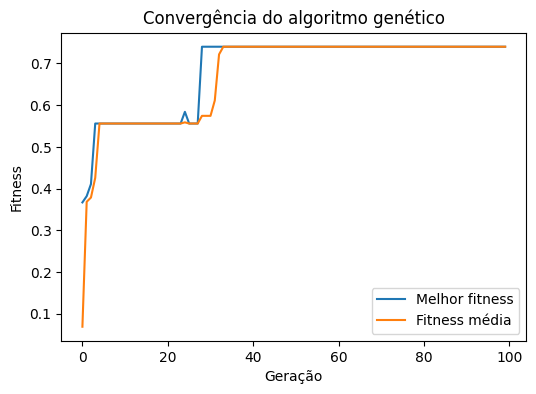

In [ ]:
#@title **Convergence plot**
plt.figure(figsize=(6,4))
plt.plot(history['best'], label='Melhor fitness')
plt.plot(history['average'], label='Fitness média')
plt.xlabel('Geração')
plt.ylabel('Fitness')
plt.legend()
plt.title('Convergência do algoritmo genético')
plt.show()